# SOTA LSTM — local eval / monitor (direct-output baseline)

Scores the **direct-output** SOTA LSTM trained in
[`train_lstm_sota_nocond.ipynb`](train_lstm_sota_nocond.ipynb) using the
**same audio-metric table** (`src.losses.compute_all_losses`) and the **same
song-level validation split** as the GR-prediction eval
([`../03_initial_GR_pred/eval_lstm.ipynb`](../03_initial_GR_pred/eval_lstm.ipynb)).

For visual comparison with the GR predictors, the preview cell also **derives a
gain-reduction curve** from the predicted/target audio (1024-sample moving RMS →
dB) and plots target-vs-predicted GR in the same 3-panel layout as the GR eval.

The validation CSV is written as `eval_audio_metrics_validation.csv` inside the
run folder — identical schema to the GR runs, so the two approaches can be
concatenated into one comparison table.

Runs on the **laptop** (reads Drive-synced run folders). No Colab needed.

> Requirements: `uv sync` at repo root.

In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import os, sys, glob, json, gc, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import lightning as pl

warnings.filterwarnings("ignore", category=UserWarning)

# Reuse the shared eval helpers that live next to the GR eval notebook.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "02b_sota_training" else Path.cwd()
GR_DIR = REPO_ROOT / "03_initial_GR_pred"
if str(GR_DIR) not in sys.path:
    sys.path.insert(0, str(GR_DIR))

from src.losses import compute_all_losses
# Same GR DSP helpers the GR predictor uses, so derived GR curves are
# directly comparable (1024-sample windowed RMS, dB gain reduction).
from src.dsp_torch import RMS_WINDOW, GR_DB_MIN, GR_DB_MAX, gain_reduction_db
from eval_helpers import (
    _checkpoint_sort_key, latest_best_checkpoint, list_runs, plot_loss_curves,
    same_setting_pairs, _read_dry_wet_segment, _pair_num_frames,
    _song_from_dry_path, _validation_pairs_from_training_split,
    _weighted_average_metric_rows, _find_hparams_json,
)

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR  = "/Volumes/Saola's Drive/AllCode/thesis/data/sota_lstm_runs"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}  |  device: {DEVICE}  |  RMS window: {RMS_WINDOW}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu  |  RMS window: 1024


In [2]:
# ── 1. List available SOTA-LSTM runs ─────────────────────────────────

assert RUNS_DIR and os.path.isdir(RUNS_DIR), f"RUNS_DIR not found: {RUNS_DIR}"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, "No runs found yet."

available_df = runs_df[runs_df["type"] == "sota_direct_output_lstm"].copy()
assert not available_df.empty, "No SOTA direct-output LSTM runs found."

cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available SOTA-LSTM runs: {len(available_df)}")
display(available_df[cols])

Available SOTA-LSTM runs: 3


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
0,sota_lstm_20260604_183657_sota_lstm,sota_direct_output_lstm,200,0.000011,44,best-199-73000.ckpt,2026-06-05 09:24:12.789447546
1,sota_lstm_20260605_104120_sota_lstm_stateful_l...,sota_direct_output_lstm,23,0.214223,8,best-023-91440.ckpt,2026-06-05 10:59:39.951478243
2,sota_lstm_20260605_112404_sota_lstm_stateful_l...,sota_direct_output_lstm,46,0.284196,13,best-041-19992.ckpt,2026-06-05 11:25:23.812086344


In [3]:
# ── 2. Select run and checkpoint ─────────────────────────────────────

# Defaults to the most recent run; set explicitly to pin one.
SELECTED_RUN_NAME = str(available_df.iloc[-1]["run"])

matches = available_df[available_df["run"] == SELECTED_RUN_NAME]
assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(RUN_DIR, "checkpoints", "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    print(f"  {os.path.basename(c):<36}  {os.path.getsize(c)/1e6:6.2f} MB{marker}")

Selected run   : sota_lstm_20260605_112404_sota_lstm_stateful_l1mrstft_longer_segment
Eval checkpoint: best-041-19992.ckpt
Best val loss  : 0.284196
Checkpoints    :
  last.ckpt                               0.03 MB
  epoch-004.ckpt                          0.03 MB
  epoch-009.ckpt                          0.03 MB
  epoch-014.ckpt                          0.03 MB
  epoch-019.ckpt                          0.03 MB
  epoch-024.ckpt                          0.03 MB
  epoch-029.ckpt                          0.03 MB
  epoch-034.ckpt                          0.03 MB
  epoch-039.ckpt                          0.03 MB
  best-039-19040.ckpt                     0.03 MB
  best-040-19516.ckpt                     0.03 MB
  best-041-19992.ckpt                     0.03 MB <-- eval
  epoch-044.ckpt                          0.03 MB


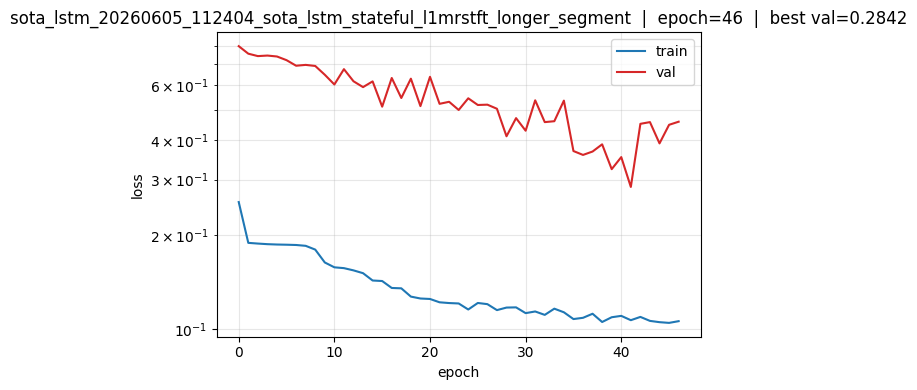

In [4]:
# ── 3. Loss curves ───────────────────────────────────────────────────

_ = plot_loss_curves(RUN_DIR)

In [5]:
# ── 4. Model definition & checkpoint loader ──────────────────────────
# OpticalLSTM_NoCond / SOTALSTMSystem must match train_lstm_sota_nocond.ipynb.


class OpticalLSTM_NoCond(nn.Module):
    def __init__(self, window: int = 64, units: int = 6):
        super().__init__()
        self.window = window
        self.proj = nn.Conv1d(1, 2, kernel_size=window, stride=1)
        self.lstm1 = nn.LSTM(2, units, batch_first=True)
        self.dense_mid = nn.Linear(units, 2)
        self.lstm2 = nn.LSTM(2, units, batch_first=True)
        self.dense_out = nn.Linear(units, 1)

    def forward(self, dry: torch.Tensor) -> torch.Tensor:
        cur = dry[:, :, self.window - 1:]
        x = self.proj(dry).transpose(1, 2)
        x, _ = self.lstm1(x)
        x = self.dense_mid(x)
        x, _ = self.lstm2(x)
        x = self.dense_out(x).transpose(1, 2)
        return cur * x


class SOTALSTMSystem(pl.LightningModule):
    def __init__(self, model: nn.Module, window: int = 64, lr: float = 3e-4,
                 planned_steps: int = 100_000):
        super().__init__()
        self.model = model
        self.window = window
        self.lr = lr
        self.planned_steps = max(1, planned_steps)

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr)
        denom = self.planned_steps * 30.0
        sched = torch.optim.lr_scheduler.LambdaLR(
            opt, lr_lambda=lambda step: 0.25 ** (step / denom))
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "interval": "step"}}


def load_system_from_ckpt(ckpt_path: str, hparams_path: str | None = None):
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), f"hparams.json not found near {ckpt_path}"
    with open(hparams_path) as f:
        hp = json.load(f)
    window = int(hp.get("window", 64))
    model = OpticalLSTM_NoCond(window=window, units=int(hp.get("units", 6)))
    system = SOTALSTMSystem.load_from_checkpoint(
        ckpt_path, model=model, window=window, map_location=DEVICE)
    system.to(DEVICE).eval()
    return system, hp


print("SOTA LSTM model + loader registered.")

SOTA LSTM model + loader registered.


In [6]:
# ── 5. Chunked prediction (constant memory, exact alignment) ─────────
#
# For a chunk [start, stop) the model needs `window-1` samples of left
# context.  We read a pre-roll and left-pad with zeros at the file head so
# the model output aligns exactly to [start, stop) (length == chunk length).


@torch.no_grad()
def predict_wet_chunk(system, window, dry_path, wet_path, start, stop, sr, device):
    pre_roll = window - 1
    context_start = max(0, start - pre_roll)
    dry_ctx, wet_ctx = _read_dry_wet_segment(dry_path, wet_path, context_start, stop, sr)
    context_offset = start - context_start            # real samples before `start`
    pad_left = pre_roll - context_offset              # >= 0
    dry_in = dry_ctx
    if pad_left > 0:
        dry_in = torch.cat([torch.zeros(dry_ctx.shape[0], pad_left), dry_ctx], dim=-1)

    with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
        pred = system(dry_in.unsqueeze(0).to(device))   # [1,1,T]  (T == stop-start)
    pred = pred.squeeze(0).float().cpu()                # [1,T]

    n = min(pred.shape[-1], stop - start, wet_ctx.shape[-1] - context_offset)
    pred = pred[..., :n]
    wet_chunk = wet_ctx[..., context_offset:context_offset + n]
    dry_chunk = dry_ctx[..., context_offset:context_offset + n]
    return dry_chunk, wet_chunk, pred

Running GR-curve preview on best-041-19992.ckpt


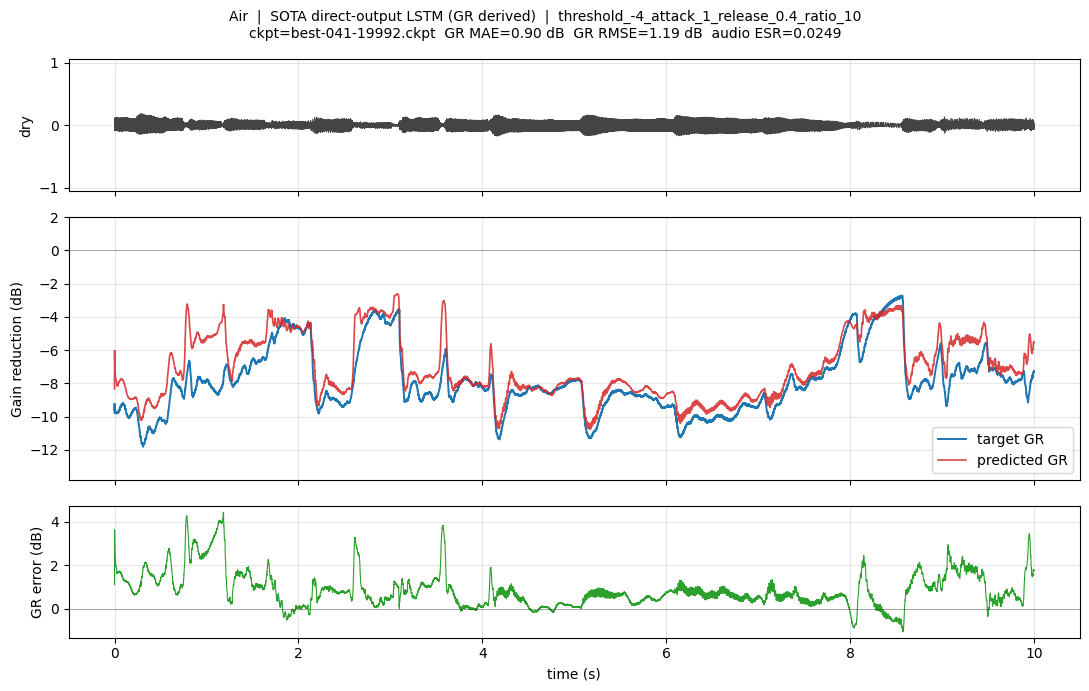

In [7]:
# ── 6. GR-curve preview (RMS-derived, mirrors the GR predictors) ─────
#
# The SOTA model predicts the wet output directly, so to compare against
# 03_initial_GR_pred/eval_lstm.ipynb we DERIVE a gain-reduction curve
# post-hoc from the moving RMS of the audio (same 1024-sample helper):
#
#   GR(t) = 20*log10(rms(out)) - 20*log10(rms(dry))
#
# computed for the target wet AND the predicted wet, then plotted in the
# same 3-panel layout (dry waveform / GR dB target-vs-pred / GR error dB).


@torch.no_grad()
def predict_gr_curves(ckpt_path, dry_wav_path, wet_wav_path,
                      start_sec=20.0, duration_sec=6.0, hparams_path=None,
                      rms_window=RMS_WINDOW):
    system, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    sr = int(hp["sample_rate"]); window = int(hp.get("window", 64))
    start = int(round(start_sec * sr)); stop = start + int(round(duration_sec * sr))

    dry, wet, pred = predict_wet_chunk(system, window, dry_wav_path, wet_wav_path,
                                       start, stop, sr, torch.device(DEVICE))

    # Derive GR (dB) from moving RMS — identical helper to the GR predictor,
    # so these curves live in the same space as the GR-prediction targets.
    gr_true = gain_reduction_db(dry.float(), wet.float(), rms_window).squeeze().cpu().numpy()
    gr_pred = gain_reduction_db(dry.float(), pred.float(), rms_window).squeeze().cpu().numpy()
    err = gr_pred - gr_true
    audio_losses = compute_all_losses(pred.unsqueeze(0), wet.unsqueeze(0))
    song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")

    return {
        "song": song, "setting": hp["setting"], "sample_rate": sr,
        "time": np.arange(len(gr_true)) / sr,
        "dry": dry.squeeze().cpu().numpy(),
        "gr_true": gr_true, "gr_pred": gr_pred, "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
        "audio_esr": float(audio_losses["ESR"]),
        "hparams": hp,
    }


@torch.no_grad()
def visualize_prediction(ckpt_path, dry_wav_path=None, wet_wav_path=None,
                         start_sec=20.0, duration_sec=6.0, hparams_path=None,
                         rms_window=RMS_WINDOW, title=None):
    _, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
    if dry_wav_path is None:
        dry_wav_path, wet_wav_path = pairs[0]
    elif wet_wav_path is None:
        song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")
        wet_wav_path = os.path.join(DATA_ROOT, "processed_ground_truth", hp["setting"], f"{song}-exported.wav")

    c = predict_gr_curves(ckpt_path, dry_wav_path, wet_wav_path,
                          start_sec=start_sec, duration_sec=duration_sec,
                          hparams_path=hparams_path, rms_window=rms_window)
    t = c["time"]

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 1]})
    axes[0].plot(t, c["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, c["gr_true"], label="target GR", lw=1.4, color="#1f77b4")
    axes[1].plot(t, c["gr_pred"], label="predicted GR", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("Gain reduction (dB)")
    lo = float(min(c["gr_true"].min(), c["gr_pred"].min()))
    axes[1].set_ylim(max(GR_DB_MIN, min(lo - 2, -2)), 2)
    axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)

    axes[2].plot(t, c["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("GR error (dB)"); axes[2].set_xlabel("time (s)"); axes[2].grid(alpha=0.3)

    ttl = title or (
        f"{c['song']}  |  SOTA direct-output LSTM (GR derived)  |  {c['setting']}\n"
        f"ckpt={os.path.basename(ckpt_path)}  "
        f"GR MAE={c['mae_db']:.2f} dB  GR RMSE={c['rmse_db']:.2f} dB  audio ESR={c['audio_esr']:.4f}"
    )
    fig.suptitle(ttl, fontsize=10); plt.tight_layout(); plt.show()
    return c


print(f"Running GR-curve preview on {os.path.basename(EVAL_CKPT_PATH)}")
_ = visualize_prediction(EVAL_CKPT_PATH, start_sec=20.0, duration_sec=10.0)

In [8]:
# ── 7. Validation-set audio metrics (same table & split as GR eval) ──
#
# Reconstructs the identical song-level validation split used during
# training, predicts wet audio in chunks, scores each chunk with
# src.losses.compute_all_losses, then reports ONE duration-weighted row.
# Saved as eval_audio_metrics_validation.csv (same schema as the GR runs).

MAX_VALIDATION_SONGS: int | None = None      # int for a quick smoke test
EVAL_VALIDATION_SONGS: list[str] | None = None
WHOLE_SONG_CHUNK_SEC = 10.0
SAVE_CHUNK_METRICS = False

metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

system, hp = load_system_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
sr = int(hp["sample_rate"]); window = int(hp.get("window", 64))
device = torch.device(DEVICE)
chunk_frames = int(round(WHOLE_SONG_CHUNK_SEC * sr))

all_pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
eval_pairs = _validation_pairs_from_training_split(all_pairs, hp)

if EVAL_VALIDATION_SONGS is not None:
    names = set(EVAL_VALIDATION_SONGS)
    eval_pairs = [(d, w) for d, w in eval_pairs if _song_from_dry_path(d) in names]
if MAX_VALIDATION_SONGS is not None:
    eval_pairs = eval_pairs[:MAX_VALIDATION_SONGS]
assert eval_pairs, "No validation pairs selected."

chunk_rows = []
for song_idx, (dry_path, wet_path) in enumerate(eval_pairs, start=1):
    song = _song_from_dry_path(dry_path)
    total_frames = _pair_num_frames(dry_path, wet_path, sr)
    print(f"[{song_idx}/{len(eval_pairs)}] {song} ({total_frames/sr:.1f}s, {WHOLE_SONG_CHUNK_SEC:.0f}s chunks)")

    for chunk_idx, start in enumerate(range(0, total_frames, chunk_frames), start=1):
        stop = min(start + chunk_frames, total_frames)
        dry_chunk, wet_chunk, pred = predict_wet_chunk(
            system, window, dry_path, wet_path, start, stop, sr, device)
        if pred.shape[-1] <= 0:
            continue
        losses = compute_all_losses(pred.unsqueeze(0), wet_chunk.unsqueeze(0))
        chunk_rows.append({"Song": song, "Chunk": chunk_idx, "Start (s)": start / sr,
                           "Duration (s)": pred.shape[-1] / sr, "Frames": pred.shape[-1],
                           **losses})
        del dry_chunk, wet_chunk, pred
        if device.type == "cuda":
            torch.cuda.empty_cache()
    gc.collect()

assert chunk_rows, "No validation chunks evaluated."

weighted = _weighted_average_metric_rows(chunk_rows, metric_cols)
total_frames = sum(r["Frames"] for r in chunk_rows)
validation_metrics_df = pd.DataFrame([{
    "Split": "validation", "Model": "sota_lstm_direct", "Run": RUN_NAME,
    "Songs": len(eval_pairs), "Chunks": len(chunk_rows),
    "Duration (s)": total_frames / sr, **weighted,
}])

out_csv = Path(RUN_DIR) / "eval_audio_metrics_validation.csv"
validation_metrics_df.to_csv(out_csv, index=False)
print(f"Saved validation audio metrics -> {out_csv}")
if SAVE_CHUNK_METRICS:
    pd.DataFrame(chunk_rows).to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv", index=False)

display(validation_metrics_df)

Validation split: 2 validation songs, 8 train songs (seed=42, train_split=0.8)
Validation songs: ['Borderline', 'NosPalpitants']
[1/2] Borderline (273.9s, 10s chunks)
[2/2] NosPalpitants (198.1s, 10s chunks)
Saved validation audio metrics -> /Volumes/Saola's Drive/AllCode/thesis/data/sota_lstm_runs/sota_lstm_20260605_112404_sota_lstm_stateful_l1mrstft_longer_segment/eval_audio_metrics_validation.csv


,Split,Model,Run,Songs,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,sota_lstm_direct,sota_lstm_20260605_112404_sota_lstm_stateful_l...,2,48,471.969365,0.0035,0.000025,0.106251,0.272255,0.233305,0.262556,0.367962


## Side-by-side comparison with the GR approaches

Each GR run folder under `gr_pred_runs/` and each SOTA run under
`sota_lstm_runs/` writes an `eval_audio_metrics_validation.csv` with the same
metric columns. The cell below collects them all into one table so the
direct-output SOTA LSTM can be compared one-to-one against the GR predictors
on the identical validation split.

In [9]:
# ── 8. Collect all eval CSVs (GR + SOTA) into one comparison table ───

GR_RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"

rows = []
for runs_root, tag in [(GR_RUNS_DIR, "gr"), (RUNS_DIR, "sota")]:
    for csv_path in sorted(glob.glob(os.path.join(runs_root, "*", "eval_audio_metrics_validation.csv"))):
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            continue
        run_name = Path(csv_path).parent.name
        df.insert(0, "Group", tag)
        if "Run" not in df.columns:
            df.insert(1, "Run", run_name)
        rows.append(df)

if rows:
    comparison = pd.concat(rows, ignore_index=True)
    front = [c for c in ["Group", "Run", "Model", "Split", "Songs", "Chunks", "Duration (s)"] if c in comparison.columns]
    comparison = comparison[front + [c for c in comparison.columns if c not in front]]
    display(comparison)
    comparison.to_csv(os.path.join(RUNS_DIR, "comparison_gr_vs_sota.csv"), index=False)
    print(f"Saved -> {os.path.join(RUNS_DIR, 'comparison_gr_vs_sota.csv')}")
else:
    print("No eval CSVs found yet. Run cell 7 here and the GR eval notebook first.")

,Group,Run,Model,Split,Songs,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,gr,gcn_gr_20260427_104716_gcn_split_fix,NaN,validation,2,48,471.969365,0.001680,6.455294e-06,0.030155,0.081990,0.188358,0.099824,0.134889
1,gr,lstm_gr_20260507_190047_lstm_v2,NaN,validation,2,48,471.969365,0.001692,6.621069e-06,0.031060,0.082849,0.207258,0.103705,0.134340
2,gr,lstm_gr_20260520_121432_lstm_v3_discretized,NaN,validation,2,48,471.969365,0.001790,7.490407e-06,0.034083,0.091866,0.188338,0.115815,0.140327
3,gr,lstm_gr_20260524_140754_lstm_v3_discretized_ab...,NaN,validation,12,305,2997.151020,0.000214,2.447429e-07,0.012815,0.061020,0.116483,0.092125,0.081792
4,gr,tcn_gr_20260427_094122_with_recommendations_h100,NaN,validation,2,48,471.969365,0.001532,5.440691e-06,0.025478,0.065513,0.130651,0.077587,0.127216
5,sota,sota_lstm_20260604_183657_sota_lstm,sota_lstm_direct,validation,2,48,471.969365,0.002251,1.043290e-05,0.046770,0.148684,0.251937,0.149665,0.245408
6,sota,sota_lstm_20260605_104120_sota_lstm_stateful_l...,sota_lstm_direct,validation,2,48,471.969365,0.005543,5.832806e-05,0.243117,0.439424,0.271014,0.451621,0.468498
7,sota,sota_lstm_20260605_112404_sota_lstm_stateful_l...,sota_lstm_direct,validation,2,48,471.969365,0.003500,2.516547e-05,0.106251,0.272255,0.233305,0.262556,0.367962


Saved -> /Volumes/Saola's Drive/AllCode/thesis/data/sota_lstm_runs/comparison_gr_vs_sota.csv


In [ ]:
# ── 9. Head-to-head: first model vs new model ────────────────────────
#
# A = first run  (stateless, fresh-state random crops, MSE loss)
# B = new run    (stateful TBPTT, L1 + MR-STFT loss)
# Same architecture (Optical-DRC create_model_LSTM), same val split, same
# chunked stateless inference -> a fair comparison.  Metric rows are read
# from each run's eval_audio_metrics_validation.csv (run cell 7 per run to
# populate them); the GR-curve overlay shows whether the -5 dB ceiling lifts.

sota_runs = available_df["run"].tolist()
RUN_A = sota_runs[0]     # earliest = first / stateless / MSE
RUN_B = sota_runs[-1]    # latest   = new / stateful / L1+MR-STFT
print(f"A (first): {RUN_A}")
print(f"B (new):   {RUN_B}")


def _run_dir(name):
    return os.path.join(RUNS_DIR, name)


def _metric_row(run):
    p = os.path.join(_run_dir(run), "eval_audio_metrics_validation.csv")
    if not os.path.isfile(p):
        return None
    df = pd.read_csv(p)
    hp = json.load(open(os.path.join(_run_dir(run), "hparams.json")))
    df["Run"] = run
    df["training"] = hp.get("training", "stateless_random_crops")
    df["loss"] = hp.get("loss", "?")
    df["epochs"] = int(available_df.set_index("run").loc[run, "epoch"])
    return df


rows = [r for r in (_metric_row(RUN_A), _metric_row(RUN_B)) if r is not None]
if len(rows) == 2:
    cmp = pd.concat(rows, ignore_index=True)
    show = ["Run", "training", "loss", "epochs", "MAE (L1)", "MSE (L2)",
            "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]
    display(cmp[[c for c in show if c in cmp.columns]])
else:
    print("Missing a metrics CSV — set SELECTED_RUN_NAME to each run and run cell 7 first.")


# ── GR-curve overlay (target vs A vs B) for one validation song ──────
COMPARE_SONG = "Borderline"     # a validation song
START_SEC, DUR_SEC = 20.0, 10.0


def _gr_for_run(run, song, start_sec, dur_sec, rms_window=RMS_WINDOW):
    ckpt = latest_best_checkpoint(_run_dir(run))
    system, hp = load_system_from_ckpt(ckpt, os.path.join(_run_dir(run), "hparams.json"))
    sr = int(hp["sample_rate"]); window = int(hp.get("window", 64))
    dry_path = os.path.join(DATA_ROOT, "processed_normalized", f"{song}_UnmasteredWAV.wav")
    wet_path = os.path.join(DATA_ROOT, "processed_ground_truth", hp["setting"], f"{song}-exported.wav")
    start = int(start_sec * sr); stop = start + int(dur_sec * sr)
    dry, wet, pred = predict_wet_chunk(system, window, dry_path, wet_path, start, stop, sr, torch.device(DEVICE))
    gr_true = gain_reduction_db(dry.float(), wet.float(), rms_window).squeeze().cpu().numpy()
    gr_pred = gain_reduction_db(dry.float(), pred.float(), rms_window).squeeze().cpu().numpy()
    return sr, gr_true, gr_pred


srA, gt, gpA = _gr_for_run(RUN_A, COMPARE_SONG, START_SEC, DUR_SEC)
_,   _,  gpB = _gr_for_run(RUN_B, COMPARE_SONG, START_SEC, DUR_SEC)
n = min(len(gt), len(gpA), len(gpB)); t = np.arange(n) / srA

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(t, gt[:n], label="target GR", lw=1.6, color="#1f77b4")
axes[0].plot(t, gpA[:n], label="A: first (stateless / MSE)", lw=1.1, color="#d62728", alpha=0.85)
axes[0].plot(t, gpB[:n], label="B: new (stateful / L1+MR-STFT)", lw=1.1, color="#2ca02c", alpha=0.85)
axes[0].axhline(0, color="k", lw=0.5, alpha=0.4)
lo = float(min(gt[:n].min(), gpA[:n].min(), gpB[:n].min()))
axes[0].set_ylim(max(GR_DB_MIN, lo - 2), 2)
axes[0].set_ylabel("Gain reduction (dB)")
axes[0].set_title(f"{COMPARE_SONG} [{START_SEC:.0f}-{START_SEC + DUR_SEC:.0f}s] — predicted GR vs target")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

axes[1].plot(t, gpA[:n] - gt[:n], label="A error", lw=0.8, color="#d62728")
axes[1].plot(t, gpB[:n] - gt[:n], label="B error", lw=0.8, color="#2ca02c")
axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
axes[1].set_ylabel("GR error (dB)"); axes[1].set_xlabel("time (s)")
axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()